 #### Collab config & libraries

In [1]:
import os

In [2]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [3]:
# Change directory
# dir_path = '/content/drive/MyDrive/Web Analytics/Linkedin code/'
dir_path = 'C:/Users/adeli/Documents 4-Q1/Web Analytics/Final Project GitHub/web-analytics-project-repo/'
os.chdir(dir_path)
# Check
current_dir = os.getcwd()
print(current_dir)

C:\Users\adeli\Documents 4-Q1\Web Analytics\Final Project GitHub\web-analytics-project-repo


In [4]:
# Check current working directory
current_dir = os.getcwd()
print(current_dir)

C:\Users\adeli\Documents 4-Q1\Web Analytics\Final Project GitHub\web-analytics-project-repo


In [59]:
#!dir

In [ ]:
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns


In [103]:
# Specific libraries
from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

In [8]:
# pip install xgboost

#### Load data

In [31]:
#### Load the data
# file_name= "jobs_linkedin_parsed.csv"
file_name= "linkedin_converted_salaries_year.csv"
df_raw=pd.read_csv(file_name)
df_raw.drop(columns=["description", "nltk_lemmas"]).head()

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_year,salary_max_year,salary_avg_year
0,0,Software Engineering Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,70000.0,161700.0,115850.0
1,1,Software Engineer,Veracity Software Inc,Sacramento,CA,Mid-Senior level,Full-time,Other,IT Services and IT Consulting,NaN,NaN,NaN,NaN,Software Engineer,Elk Grove,Be among the first 25 applicants,40,NaN,NaN,NaN
2,2,Software Engineer,Epic,Elk Grove,CA,Entry level,Full-time,Engineering and Information Technology,Software Development,NaN,NaN,NaN,NaN,Software Engineer,Elk Grove,197 applicants,40,NaN,NaN,NaN
3,3,Software Engineer,Epic,Sacramento,CA,Entry level,Full-time,Engineering and Information Technology,Software Development,NaN,NaN,NaN,NaN,Software Engineer,Elk Grove,190 applicants,40,NaN,NaN,NaN
4,4,Software Engineering Intern,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,Over 200 applicants,40,72800.0,95680.0,84240.0


In [32]:
# Take a first look into data
print("====== Number of samples ======")
print("Number of samples: ", len(df_raw))
print("\n====== Check NAs ======")
print(df_raw.isna().sum().to_frame(name="NA_Counts"))

====== Number of samples ======
Number of samples:  10490

====== Check NAs ======
                   NA_Counts
offer_id                   0
title                      0
company_name               0
city                     408
state_code                 0
seniority_level            0
job_type                   0
job_function               5
industry                   1
description                0
salary_min              3673
salary_max              3673
salary_unit             3673
salary                  3673
searched_position          0
searched_location          0
applications               0
nltk_lemmas                0
hours_a_week               0
salary_min_year         3673
salary_max_year         3673
salary_avg_year         3673


#### Feature selection

In [34]:
# Perform several transformations to prepare data for an XGBoost model
# Add log salary column as target (can try regression on both real salary and log salary)
df_raw["salary_avg_year_log"] = np.log1p(df_raw["salary_avg_year"])

In [35]:
# Examine the meaning of 'Not Applicable' in 'seniority_level'
df_raw[df_raw["seniority_level"]=='Not Applicable'].drop(columns=["description", "nltk_lemmas"]).head()

# See that 'Not Applicable' in 'seniority_level' means entry level jobs, then meaningful, so we keep it as a category

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_year,salary_max_year,salary_avg_year,salary_avg_year_log
0,0,Software Engineering Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,70000.0,161700.0,115850.0,11.660060
4,4,Software Engineering Intern,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,Over 200 applicants,40,72800.0,95680.0,84240.0,11.341437
16,16,Firmware Engineer Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,187 applicants,40,70000.0,161700.0,115850.0,11.660060
17,17,Cloud Engineer Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,79700.0,183200.0,year,"$79,700.00/yr - $183,200.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,79700.0,183200.0,131450.0,11.786389
28,28,Cloud Engineer Intern,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,120 applicants,40,72800.0,95680.0,84240.0,11.341437


In [36]:
categorical_cols = [
    "title",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Create a copy of X to encode categorical variables
df=df_raw.copy()
for col in categorical_cols:
    df[col] = df[col].astype("category").cat.codes

In [37]:
def parse_embedding(text):
    if pd.isna(text):
        return None  # or np.full(300, np.nan)

    s = str(text).strip()
    # After visual inspection of an embedding, need to fix:
    # Remove start/end quotes if present
    if len(s) >= 2 and s[0] == s[-1] and s[0] in ("'", '"'):
        s = s[1:-1]

    # Replace escaped and real newlines with spaces
    s = s.replace("\\r\\n", " ").replace("\r\n", " ")

    # Remove brackets
    s = s.replace("[", " ").replace("]", " ")

    # Split on whitespace and convert to floats
    parts = s.split()
    return np.array([float(p) for p in parts], dtype=float)

# Apply to the column
emb_series = df["description"].apply(parse_embedding)

In [38]:
# To check whether the parsing worked correctly
sample_raw = df["description"].iloc[0]
parsed = parse_embedding(sample_raw)

print(type(parsed))          # <class 'numpy.ndarray'>
print(parsed.shape)          # (300,)
print(parsed[:5])            # first 5 numbers

<class 'numpy.ndarray'>
(300,)
[ 0.12823805 -0.24857527  0.11840297  0.01428639  0.09091719]


In [39]:
# Apply over the df once checked above
emb_series = df["description"].apply(parse_embedding)
emb_matrix = np.vstack(emb_series.values)
emb_cols = [f"desc_emb_{i}" for i in range(emb_matrix.shape[1])]
emb_df = pd.DataFrame(emb_matrix, columns=emb_cols, index=df.index)

df = pd.concat([df.drop(columns=["description"]), emb_df], axis=1)

In [40]:
df.drop(columns=["nltk_lemmas"]).head()

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_year,salary_max_year,salary_avg_year,salary_avg_year_log,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29,desc_emb_30,desc_emb_31,desc_emb_32,desc_emb_33,desc_emb_34,desc_emb_35,desc_emb_36,desc_emb_37,desc_emb_38,desc_emb_39,desc_emb_40,desc_emb_41,desc_emb_42,desc_emb_43,desc_emb_44,desc_emb_45,desc_emb_46,desc_emb_47,desc_emb_48,desc_emb_49,desc_emb_50,desc_emb_51,desc_emb_52,desc_emb_53,desc_emb_54,desc_emb_55,desc_emb_56,desc_emb_57,desc_emb_58,desc_emb_59,desc_emb_60,desc_emb_61,desc_emb_62,desc_emb_63,desc_emb_64,desc_emb_65,desc_emb_66,desc_emb_67,desc_emb_68,desc_emb_69,desc_emb_70,desc_emb_71,desc_emb_72,desc_emb_73,desc_emb_74,desc_emb_75,desc_emb_76,desc_emb_77,desc_emb_78,desc_emb_79,desc_emb_80,desc_emb_81,desc_emb_82,desc_emb_83,desc_emb_84,desc_emb_85,desc_emb_86,desc_emb_87,desc_emb_88,desc_emb_89,desc_emb_90,desc_emb_91,desc_emb_92,desc_emb_93,desc_emb_94,desc_emb_95,desc_emb_96,desc_emb_97,desc_emb_98,desc_emb_99,desc_emb_100,desc_emb_101,desc_emb_102,desc_emb_103,desc_emb_104,desc_emb_105,desc_emb_106,desc_emb_107,desc_emb_108,desc_emb_109,desc_emb_110,desc_emb_111,desc_emb_112,desc_emb_113,desc_emb_114,desc_emb_115,desc_emb_116,desc_emb_117,desc_emb_118,desc_emb_119,desc_emb_120,desc_emb_121,desc_emb_122,desc_emb_123,desc_emb_124,desc_emb_125,desc_emb_126,desc_emb_127,desc_emb_128,desc_emb_129,desc_emb_130,desc_emb_131,desc_emb_132,desc_emb_133,desc_emb_134,desc_emb_135,desc_emb_136,desc_emb_137,desc_emb_138,desc_emb_139,desc_emb_140,desc_emb_141,desc_emb_142,desc_emb_143,desc_emb_144,desc_emb_145,desc_emb_146,desc_emb_147,desc_emb_148,desc_emb_149,desc_emb_150,desc_emb_151,desc_emb_152,desc_emb_153,desc_emb_154,desc_emb_155,desc_emb_156,desc_emb_157,desc_emb_158,desc_emb_159,desc_emb_160,desc_emb_161,desc_emb_162,desc_emb_163,desc_emb_164,desc_emb_165,desc_emb_166,desc_emb_167,desc_emb_168,desc_emb_169,desc_emb_170,desc_emb_171,desc_emb_172,desc_emb_173,desc_emb_174,desc_emb_175,desc_emb_176,desc_emb_177,desc_emb_178,desc_emb_179,desc_emb_180,desc_emb_181,desc_emb_182,desc_emb_183,desc_emb_184,desc_emb_185,desc_emb_186,desc_emb_187,desc_emb_188,desc_emb_189,desc_emb_190,desc_emb_191,desc_emb_192,desc_emb_193,desc_emb_194,desc_emb_195,desc_emb_196,desc_emb_197,desc_emb_198,desc_emb_199,desc_emb_200,desc_emb_201,desc_emb_202,desc_emb_203,desc_emb_204,desc_emb_205,desc_emb_206,desc_emb_207,desc_emb_208,desc_emb_209,desc_emb_210,desc_emb_211,desc_emb_212,desc_emb_213,desc_emb_214,desc_emb_215,desc_emb_216,desc_emb_217,desc_emb_218,desc_emb_219,desc_emb_220,desc_emb_221,desc_emb_222,desc_emb_223,desc_emb_224,desc_emb_225,desc_emb_226,desc_emb_227,desc_emb_228,desc_emb_229,desc_emb_230,desc_emb_231,desc_emb_232,desc_emb_233,desc_emb_234,desc_emb_235,desc_emb_236,desc_emb_237,desc_emb_238,desc_emb_239,desc_emb_240,desc_emb_241,desc_emb_242,desc_emb_243,desc_emb_244,desc_emb_245,desc_emb_246,desc_emb_247,desc_emb_248,desc_emb_249,desc_emb_250,desc_emb_251,desc_emb_252,desc_emb_253,desc_emb_254,desc_emb_255,desc_emb_256,desc_emb_257,desc_emb_258,desc_emb_259,desc_emb_260,desc_emb_261,desc_emb_262,desc_emb_263,desc_emb_264,desc_emb_265,desc_emb_266,desc_emb_267,desc_emb_268,desc_emb_269,desc_emb_270,desc_emb_271,desc_emb_272,desc_emb_273,desc_emb_274,desc_emb_275,desc_emb_276,desc_emb_277,desc_emb_278,desc_emb_279,desc_emb_280,desc_emb_281,desc_emb_282,desc_emb_283,desc_emb_284,desc_emb_285,desc_emb_286,desc_emb_287,desc_emb_288,desc_emb_289,desc_emb_290,desc_emb_291,desc_emb_292,desc_emb_293,desc_emb_294,desc_emb_295

In [ ]:
# As state is always 'CA', does not add information
df = df.drop(columns=["state_code"], errors="ignore")

In [ ]:
# Separate dataset in with and without salary
has_salary = df["salary_min"].notna() | df["salary_max"].notna()
df_train_val = df[has_salary].copy()
df_test = df[~has_salary].copy()

In [45]:
df_train_val.drop(columns=["nltk_lemmas"]).head(2)

,offer_id,title,company_name,city,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_year,salary_max_year,salary_avg_year,salary_avg_year_log,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29,desc_emb_30,desc_emb_31,desc_emb_32,desc_emb_33,desc_emb_34,desc_emb_35,desc_emb_36,desc_emb_37,desc_emb_38,desc_emb_39,desc_emb_40,desc_emb_41,desc_emb_42,desc_emb_43,desc_emb_44,desc_emb_45,desc_emb_46,desc_emb_47,desc_emb_48,desc_emb_49,desc_emb_50,desc_emb_51,desc_emb_52,desc_emb_53,desc_emb_54,desc_emb_55,desc_emb_56,desc_emb_57,desc_emb_58,desc_emb_59,desc_emb_60,desc_emb_61,desc_emb_62,desc_emb_63,desc_emb_64,desc_emb_65,desc_emb_66,desc_emb_67,desc_emb_68,desc_emb_69,desc_emb_70,desc_emb_71,desc_emb_72,desc_emb_73,desc_emb_74,desc_emb_75,desc_emb_76,desc_emb_77,desc_emb_78,desc_emb_79,desc_emb_80,desc_emb_81,desc_emb_82,desc_emb_83,desc_emb_84,desc_emb_85,desc_emb_86,desc_emb_87,desc_emb_88,desc_emb_89,desc_emb_90,desc_emb_91,desc_emb_92,desc_emb_93,desc_emb_94,desc_emb_95,desc_emb_96,desc_emb_97,desc_emb_98,desc_emb_99,desc_emb_100,desc_emb_101,desc_emb_102,desc_emb_103,desc_emb_104,desc_emb_105,desc_emb_106,desc_emb_107,desc_emb_108,desc_emb_109,desc_emb_110,desc_emb_111,desc_emb_112,desc_emb_113,desc_emb_114,desc_emb_115,desc_emb_116,desc_emb_117,desc_emb_118,desc_emb_119,desc_emb_120,desc_emb_121,desc_emb_122,desc_emb_123,desc_emb_124,desc_emb_125,desc_emb_126,desc_emb_127,desc_emb_128,desc_emb_129,desc_emb_130,desc_emb_131,desc_emb_132,desc_emb_133,desc_emb_134,desc_emb_135,desc_emb_136,desc_emb_137,desc_emb_138,desc_emb_139,desc_emb_140,desc_emb_141,desc_emb_142,desc_emb_143,desc_emb_144,desc_emb_145,desc_emb_146,desc_emb_147,desc_emb_148,desc_emb_149,desc_emb_150,desc_emb_151,desc_emb_152,desc_emb_153,desc_emb_154,desc_emb_155,desc_emb_156,desc_emb_157,desc_emb_158,desc_emb_159,desc_emb_160,desc_emb_161,desc_emb_162,desc_emb_163,desc_emb_164,desc_emb_165,desc_emb_166,desc_emb_167,desc_emb_168,desc_emb_169,desc_emb_170,desc_emb_171,desc_emb_172,desc_emb_173,desc_emb_174,desc_emb_175,desc_emb_176,desc_emb_177,desc_emb_178,desc_emb_179,desc_emb_180,desc_emb_181,desc_emb_182,desc_emb_183,desc_emb_184,desc_emb_185,desc_emb_186,desc_emb_187,desc_emb_188,desc_emb_189,desc_emb_190,desc_emb_191,desc_emb_192,desc_emb_193,desc_emb_194,desc_emb_195,desc_emb_196,desc_emb_197,desc_emb_198,desc_emb_199,desc_emb_200,desc_emb_201,desc_emb_202,desc_emb_203,desc_emb_204,desc_emb_205,desc_emb_206,desc_emb_207,desc_emb_208,desc_emb_209,desc_emb_210,desc_emb_211,desc_emb_212,desc_emb_213,desc_emb_214,desc_emb_215,desc_emb_216,desc_emb_217,desc_emb_218,desc_emb_219,desc_emb_220,desc_emb_221,desc_emb_222,desc_emb_223,desc_emb_224,desc_emb_225,desc_emb_226,desc_emb_227,desc_emb_228,desc_emb_229,desc_emb_230,desc_emb_231,desc_emb_232,desc_emb_233,desc_emb_234,desc_emb_235,desc_emb_236,desc_emb_237,desc_emb_238,desc_emb_239,desc_emb_240,desc_emb_241,desc_emb_242,desc_emb_243,desc_emb_244,desc_emb_245,desc_emb_246,desc_emb_247,desc_emb_248,desc_emb_249,desc_emb_250,desc_emb_251,desc_emb_252,desc_emb_253,desc_emb_254,desc_emb_255,desc_emb_256,desc_emb_257,desc_emb_258,desc_emb_259,desc_emb_260,desc_emb_261,desc_emb_262,desc_emb_263,desc_emb_264,desc_emb_265,desc_emb_266,desc_emb_267,desc_emb_268,desc_emb_269,desc_emb_270,desc_emb_271,desc_emb_272,desc_emb_273,desc_emb_274,desc_emb_275,desc_emb_276,desc_emb_277,desc_emb_278,desc_emb_279,desc_emb_280,desc_emb_281,desc_emb_282,desc_emb_283,desc_emb_284,desc_emb_285,desc_emb_286,desc_emb_287,desc_emb_288,desc_emb_289,desc_emb_290,desc_emb_291,desc_emb_292,desc_emb_293,desc_emb_294,desc_emb_295,desc_emb_2

In [ ]:
# LEave in X only the feature columns we are interested in
categorical_cols = [
    "title",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Generate embedding column names: desc_emb_0 to desc_emb_299
embedding_cols = [f"desc_emb_{i}" for i in range(300)]

# Union of both lists
feature_cols = categorical_cols + embedding_cols

# Keep only feature columns in X
X = df_train_val[feature_cols]
# Set as target the log avg salary
y = df_train_val["salary_avg_year_log"]
# y = df_train_val["salary_avg_year"] # To try predicting the real salary instead of log

In [137]:
y.values[:10]

array([11.66006016, 11.34143702, 11.77529742, 12.0435596 , 11.76026199,
       12.0435596 , 11.66006016, 11.78638944, 11.28988441, 11.52440927])

In [48]:
X.head()

,title,company_name,city,seniority_level,job_type,job_function,industry,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29,desc_emb_30,desc_emb_31,desc_emb_32,desc_emb_33,desc_emb_34,desc_emb_35,desc_emb_36,desc_emb_37,desc_emb_38,desc_emb_39,desc_emb_40,desc_emb_41,desc_emb_42,desc_emb_43,desc_emb_44,desc_emb_45,desc_emb_46,desc_emb_47,desc_emb_48,desc_emb_49,desc_emb_50,desc_emb_51,desc_emb_52,desc_emb_53,desc_emb_54,desc_emb_55,desc_emb_56,desc_emb_57,desc_emb_58,desc_emb_59,desc_emb_60,desc_emb_61,desc_emb_62,desc_emb_63,desc_emb_64,desc_emb_65,desc_emb_66,desc_emb_67,desc_emb_68,desc_emb_69,desc_emb_70,desc_emb_71,desc_emb_72,desc_emb_73,desc_emb_74,desc_emb_75,desc_emb_76,desc_emb_77,desc_emb_78,desc_emb_79,desc_emb_80,desc_emb_81,desc_emb_82,desc_emb_83,desc_emb_84,desc_emb_85,desc_emb_86,desc_emb_87,desc_emb_88,desc_emb_89,desc_emb_90,desc_emb_91,desc_emb_92,desc_emb_93,desc_emb_94,desc_emb_95,desc_emb_96,desc_emb_97,desc_emb_98,desc_emb_99,desc_emb_100,desc_emb_101,desc_emb_102,desc_emb_103,desc_emb_104,desc_emb_105,desc_emb_106,desc_emb_107,desc_emb_108,desc_emb_109,desc_emb_110,desc_emb_111,desc_emb_112,desc_emb_113,desc_emb_114,desc_emb_115,desc_emb_116,desc_emb_117,desc_emb_118,desc_emb_119,desc_emb_120,desc_emb_121,desc_emb_122,desc_emb_123,desc_emb_124,desc_emb_125,desc_emb_126,desc_emb_127,desc_emb_128,desc_emb_129,desc_emb_130,desc_emb_131,desc_emb_132,desc_emb_133,desc_emb_134,desc_emb_135,desc_emb_136,desc_emb_137,desc_emb_138,desc_emb_139,desc_emb_140,desc_emb_141,desc_emb_142,desc_emb_143,desc_emb_144,desc_emb_145,desc_emb_146,desc_emb_147,desc_emb_148,desc_emb_149,desc_emb_150,desc_emb_151,desc_emb_152,desc_emb_153,desc_emb_154,desc_emb_155,desc_emb_156,desc_emb_157,desc_emb_158,desc_emb_159,desc_emb_160,desc_emb_161,desc_emb_162,desc_emb_163,desc_emb_164,desc_emb_165,desc_emb_166,desc_emb_167,desc_emb_168,desc_emb_169,desc_emb_170,desc_emb_171,desc_emb_172,desc_emb_173,desc_emb_174,desc_emb_175,desc_emb_176,desc_emb_177,desc_emb_178,desc_emb_179,desc_emb_180,desc_emb_181,desc_emb_182,desc_emb_183,desc_emb_184,desc_emb_185,desc_emb_186,desc_emb_187,desc_emb_188,desc_emb_189,desc_emb_190,desc_emb_191,desc_emb_192,desc_emb_193,desc_emb_194,desc_emb_195,desc_emb_196,desc_emb_197,desc_emb_198,desc_emb_199,desc_emb_200,desc_emb_201,desc_emb_202,desc_emb_203,desc_emb_204,desc_emb_205,desc_emb_206,desc_emb_207,desc_emb_208,desc_emb_209,desc_emb_210,desc_emb_211,desc_emb_212,desc_emb_213,desc_emb_214,desc_emb_215,desc_emb_216,desc_emb_217,desc_emb_218,desc_emb_219,desc_emb_220,desc_emb_221,desc_emb_222,desc_emb_223,desc_emb_224,desc_emb_225,desc_emb_226,desc_emb_227,desc_emb_228,desc_emb_229,desc_emb_230,desc_emb_231,desc_emb_232,desc_emb_233,desc_emb_234,desc_emb_235,desc_emb_236,desc_emb_237,desc_emb_238,desc_emb_239,desc_emb_240,desc_emb_241,desc_emb_242,desc_emb_243,desc_emb_244,desc_emb_245,desc_emb_246,desc_emb_247,desc_emb_248,desc_emb_249,desc_emb_250,desc_emb_251,desc_emb_252,desc_emb_253,desc_emb_254,desc_emb_255,desc_emb_256,desc_emb_257,desc_emb_258,desc_emb_259,desc_emb_260,desc_emb_261,desc_emb_262,desc_emb_263,desc_emb_264,desc_emb_265,desc_emb_266,desc_emb_267,desc_emb_268,desc_emb_269,desc_emb_270,desc_emb_271,desc_emb_272,desc_emb_273,desc_emb_274,desc_emb_275,desc_emb_276,desc_emb_277,desc_emb_278,desc_emb_279,desc_emb_280,desc_emb_281,desc_emb_282,desc_emb_283,desc_emb_284,desc_emb_285,desc_emb_286,desc_emb_287,desc_emb_288,desc_emb_289,desc_emb_290,desc_emb_291,desc_emb_292,desc_emb_293,desc_emb_294,desc_emb_295,desc_emb_296,desc_emb_297,desc_emb_298,desc_emb_299
0,5352,1402,243,6,1,59,355,0.128238,-0.248575,0.118403,0.014286,0.090917,-0.306677,0.015479,-0.057601,0.109536,0.093178,-0.083272,0.072750

In [49]:
y.head()

0    11.660060
4    11.341437
5    11.775297
7    12.043560
8    11.760262
Name: salary_avg_year_log, dtype: float64

In [ ]:
# Once that we have X and y, we can split into train and validation sets
# Choose 80% for training and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=None
)

print(X_train.shape, X_val.shape)

(5453, 307) (1364, 307)


Once we have transformed and selected the columns and separated into X and y, and perform the split into train and validation, we can start the regression process.

### XGBoost

In [76]:
# Import libraries for XGBoost with early stopping
import xgboost as xgb
from xgboost.callback import EarlyStopping

In [ ]:
# Need to try this approach due to errors exec the .fit method. Likely due to an issue with the version of xgboost installed
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)


In [ ]:
XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [73]:
params = {
    "objective": "reg:squarederror",
    "eta": 0.05,               # learning_rate
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,             # reg_lambda
    "alpha": 0.0,              # reg_alpha
    "tree_method": "hist",
    "seed": 42,
}


In [ ]:
evals = [(dtrain, "train"), (dval, "val")]

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=600,        # Equiv. to n_estimators
    evals=evals,
    early_stopping_rounds=50,   # Try to provoke early stopping if no improvement on 50 rounds
    verbose_eval=True,          # print progress
)


[0]	train-rmse:0.65186	val-rmse:0.76401
[1]	train-rmse:0.63694	val-rmse:0.75385
[2]	train-rmse:0.62120	val-rmse:0.74416
[3]	train-rmse:0.60818	val-rmse:0.73785
[4]	train-rmse:0.59772	val-rmse:0.73396
[5]	train-rmse:0.58577	val-rmse:0.72513
[6]	train-rmse:0.57574	val-rmse:0.71797
[7]	train-rmse:0.56526	val-rmse:0.71287
[8]	train-rmse:0.55343	val-rmse:0.70631
[9]	train-rmse:0.54309	val-rmse:0.70080
[10]	train-rmse:0.53179	val-rmse:0.69437
[11]	train-rmse:0.52157	val-rmse:0.68823
[12]	train-rmse:0.51228	val-rmse:0.68419
[13]	train-rmse:0.50270	val-rmse:0.67909
[14]	train-rmse:0.49267	val-rmse:0.67266
[15]	train-rmse:0.48337	val-rmse:0.66717
[16]	train-rmse:0.47474	val-rmse:0.66259
[17]	train-rmse:0.46597	val-rmse:0.65889
[18]	train-rmse:0.45820	val-rmse:0.65548
[19]	train-rmse:0.45141	val-rmse:0.65387
[20]	train-rmse:0.44318	val-rmse:0.65091
[21]	train-rmse:0.43650	val-rmse:0.64730
[22]	train-rmse:0.42948	val-rmse:0.64263
[23]	train-rmse:0.42223	val-rmse:0.64162
[24]	train-rmse:0.41529	va

In [ ]:
print("Best iteration:", bst.best_iteration)
print("Best val score:", bst.best_score)
# We can see that overfitting happened 

Best iteration: 599
Best val score: 0.5592113579476558


In [89]:
# Change parameters to reduce overfitting
params = {
    "objective": "reg:squarederror",
    "eta": 0.03,          # Smaller learning rate
    "max_depth": 5,      # Reduce the depth
    "min_child_weight": 5,# Try: stronger minimum leaf constraint
    "max_depth": 6,       # Was 8; try for less deep trees
    "min_child_weight": 3,# new: avoid very small leaves
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 3.0,        # stronger L2
    "alpha": 1.0,         # add some L1
    "gamma": 0.2,         # Try greater gain to split
    "tree_method": "hist",
    "seed": 42,
}

# Define a dict to store results
evals_result = {}

# Train the model, change to store results
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=25,
    evals_result=evals_result,     
    verbose_eval=50, # Reduce the number of printed lines 
)

[0]	train-rmse:0.66165	val-rmse:0.77168
[50]	train-rmse:0.47962	val-rmse:0.65742
[100]	train-rmse:0.38813	val-rmse:0.61288
[150]	train-rmse:0.32277	val-rmse:0.59768
[200]	train-rmse:0.27479	val-rmse:0.59078
[250]	train-rmse:0.23707	val-rmse:0.58552
[300]	train-rmse:0.20792	val-rmse:0.58108
[350]	train-rmse:0.18516	val-rmse:0.57831
[400]	train-rmse:0.16878	val-rmse:0.57655
[450]	train-rmse:0.15945	val-rmse:0.57514
[500]	train-rmse:0.15691	val-rmse:0.57464
[550]	train-rmse:0.15540	val-rmse:0.57424
[600]	train-rmse:0.15448	val-rmse:0.57419
[650]	train-rmse:0.15286	val-rmse:0.57386
[700]	train-rmse:0.15217	val-rmse:0.57379
[750]	train-rmse:0.15189	val-rmse:0.57374
[757]	train-rmse:0.15172	val-rmse:0.57374


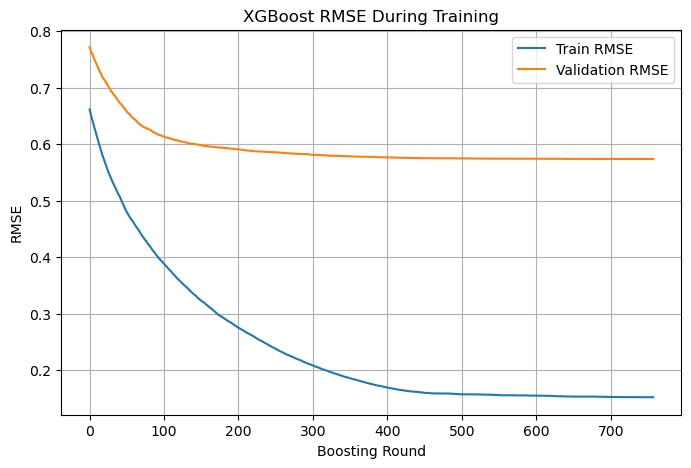

In [90]:
train_rmse = evals_result['train']['rmse']
val_rmse   = evals_result['val']['rmse']

plt.figure(figsize=(8,5))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse,   label='Validation RMSE')
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost RMSE During Training")
plt.legend()
plt.grid(True)
plt.show()

In [91]:
# Get best iteration
print("Best iteration:", bst.best_iteration)
print("Best validation RMSE:", bst.best_score)

Best iteration: 732
Best validation RMSE: 0.5737358572055203


In [ ]:
# Overfitting improved, see predictions on validation set

In [99]:
y_val_true_log = y_val
y_val_pred_log = bst.predict(dval, iteration_range=(0, bst.best_iteration+1))


In [107]:
y_val_true_log.head()

405     11.695255
9800    11.608245
9673    11.934926
8623    12.128117
3949    12.388398
Name: salary_avg_year_log, dtype: float64

In [109]:
y_val_pred_log[:5]

array([11.788184, 11.731347, 11.788004, 12.054588, 11.910229],
      dtype=float32)

In [111]:
# Metrics
# Use Log-space metrics
mae_log  = mean_absolute_error(y_val_true_log, y_val_pred_log)
medianea_log = median_absolute_error(y_val_true_log, y_val_pred_log)
mse_log  = mean_squared_error(y_val_true_log, y_val_pred_log)
rmse_log = np.sqrt(mse_log)
r2_log   = r2_score(y_val_true_log, y_val_pred_log)

print("---- Validation Performance (LOG Salary) ----")
print(f"MAE (log):   {mae_log:.4f}")
print(f"MedAE (log): {medianea_log:.4f}")
print(f"RMSE (log):  {rmse_log:.4f}")
print(f"R² (log):    {r2_log:.3f}")


---- Validation Performance (LOG Salary) ----
MAE (log):   0.2203
MedAE (log): 0.1311
RMSE (log):  0.5737
R² (log):    0.453


New result with best sweep hyperparameters:<br>

---- Validation Performance (LOG Salary) ----<br>
MAE (log):   0.2036<br>
MedAE (log): 0.1152<br>
RMSE (log):  0.5612<br>
R² (log):    0.477<br>

#### Try to improve the performance with parameter sweep

In [112]:
import wandb
wandb.login()

wandb: Currently logged in as: 100496657 (100496657-universidad-carlos-iii-de-madrid) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [113]:
def train_xgb(config=None):
    with wandb.init(config=config):
        cfg = wandb.config

        # XGBoost params from sweep config
        params = {
            "objective": "reg:squarederror",
            "eta": cfg.learning_rate,          # learning rate
            "max_depth": cfg.max_depth,
            "min_child_weight": cfg.min_child_weight,
            "subsample": cfg.subsample,
            "colsample_bytree": cfg.colsample_bytree,
            "lambda": cfg.reg_lambda,          # L2
            "alpha": cfg.reg_alpha,            # L1
            "gamma": cfg.gamma,
            "tree_method": "hist",
            "seed": 42,
        }

        evals_result = {}
        evals = [(dtrain, "train"), (dval, "val")]

        bst = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=cfg.num_boost_round,
            evals=evals,
            early_stopping_rounds=cfg.early_stopping_rounds,
            evals_result=evals_result,
            verbose_eval=False,
        )

        # --- Metrics in LOG space ---
        y_val_pred_log = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
        y_val_true_log = y_val

        mae_log  = mean_absolute_error(y_val_true_log, y_val_pred_log)
        mse_log  = mean_squared_error(y_val_true_log, y_val_pred_log)
        rmse_log = np.sqrt(mse_log)
        r2_log   = r2_score(y_val_true_log, y_val_pred_log)

        # For convenience: approximate MAPE in % (log-space)
        approx_mape = (np.exp(mae_log) - 1) * 100

        # Log everything to W&B
        wandb.log({
            "val_mae_log": mae_log,
            "val_rmse_log": rmse_log,
            "val_r2_log": r2_log,
            "val_approx_mape": approx_mape,
            "best_iteration": bst.best_iteration,
            "best_val_rmse_log_xgb": float(bst.best_score),  # xgb's rmse
        })

In [114]:
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_rmse_log", "goal": "minimize"},
    "parameters": {
        "learning_rate":    {"values": [0.02, 0.03, 0.05]},
        "max_depth":        {"values": [4, 5, 6]},
        "min_child_weight": {"values": [1, 3, 5]},
        "subsample":        {"values": [0.6, 0.7, 0.8]},
        "colsample_bytree": {"values": [0.5, 0.7, 0.8]},
        "reg_alpha":        {"values": [0.0, 0.5, 1.0]},
        "reg_lambda":       {"values": [1.0, 2.0, 3.0]},
        "gamma":            {"values": [0.0, 0.1, 0.3]},
        "num_boost_round":        {"value": 800},
        "early_stopping_rounds":  {"value": 40},
    },
}


In [115]:
sweep_id = wandb.sweep(sweep_config, project="salary_prediction_xgb")
print("Sweep ID:", sweep_id)
wandb.agent(sweep_id, function=train_xgb, count=20)

Create sweep with ID: kf9kgqnj
Sweep URL: https://wandb.ai/100496657-universidad-carlos-iii-de-madrid/salary_prediction_xgb/sweeps/kf9kgqnj
Sweep ID: kf9kgqnj


wandb: Agent Starting Run: u1bunipu with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 5
wandb: 	min_child_weight: 5
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.58002
val_approx_mape,27.17002
val_mae_log,0.24035
val_r2_log,0.44135


wandb: Agent Starting Run: b14htk10 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.56999
val_approx_mape,24.28219
val_mae_log,0.21738
val_r2_log,0.46051


wandb: Agent Starting Run: juu1xjvf with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.56948
val_approx_mape,22.93875
val_mae_log,0.20652
val_r2_log,0.46147


wandb: Agent Starting Run: ajau4b8c with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 5
wandb: 	min_child_weight: 5
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.57361
val_approx_mape,25.09606
val_mae_log,0.22391
val_r2_log,0.45363


wandb: Agent Starting Run: psux28ro with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,784
best_val_rmse_log_xgb,0.56974
val_approx_mape,23.10123
val_mae_log,0.20784
val_r2_log,0.46098


wandb: Agent Starting Run: 8faj10hd with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,666
best_val_rmse_log_xgb,0.57265
val_approx_mape,23.10095
val_mae_log,0.20783
val_r2_log,0.45547


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: x0c53wss with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,738
best_val_rmse_log_xgb,0.57113
val_approx_mape,23.01311
val_mae_log,0.20712
val_r2_log,0.45835


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: xpullrrk with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.5633
val_approx_mape,22.52219
val_mae_log,0.20312
val_r2_log,0.47311


wandb: Agent Starting Run: z5wotzat with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,703
best_val_rmse_log_xgb,0.57039
val_approx_mape,23.839
val_mae_log,0.21381
val_r2_log,0.45976


wandb: Agent Starting Run: y1v1q97e with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,796
best_val_rmse_log_xgb,0.56655
val_approx_mape,22.5229
val_mae_log,0.20313
val_r2_log,0.46701


wandb: Agent Starting Run: vc7922vp with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.56124
val_approx_mape,22.5778
val_mae_log,0.20358
val_r2_log,0.47696


wandb: Agent Starting Run: 7kogvyvo with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,645
best_val_rmse_log_xgb,0.56779
val_approx_mape,23.86256
val_mae_log,0.214
val_r2_log,0.46467


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: pe8cor8j with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,788
best_val_rmse_log_xgb,0.56753
val_approx_mape,24.52151
val_mae_log,0.21931
val_r2_log,0.46516


wandb: Agent Starting Run: 2mdjbzwl with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,796
best_val_rmse_log_xgb,0.56655
val_approx_mape,22.5229
val_mae_log,0.20313
val_r2_log,0.46701


wandb: Agent Starting Run: y2hk2tzc with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.56906
val_approx_mape,23.42143
val_mae_log,0.21043
val_r2_log,0.46228


wandb: Agent Starting Run: kuthk7ee with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,783
best_val_rmse_log_xgb,0.56967
val_approx_mape,23.64324
val_mae_log,0.21223
val_r2_log,0.46113


wandb: Agent Starting Run: dqsa3dgq with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,742
best_val_rmse_log_xgb,0.56375
val_approx_mape,22.4676
val_mae_log,0.20268
val_r2_log,0.47227


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: feba0w0e with config:
wandb: 	colsample_bytree: 0.5
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,703
best_val_rmse_log_xgb,0.57094
val_approx_mape,23.75663
val_mae_log,0.21315
val_r2_log,0.45871


wandb: Agent Starting Run: 914bp60u with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,652
best_val_rmse_log_xgb,0.56969
val_approx_mape,23.54508
val_mae_log,0.21144
val_r2_log,0.46108


wandb: Agent Starting Run: jqgtge2g with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.56574
val_approx_mape,22.60657
val_mae_log,0.20381
val_r2_log,0.46854


In [116]:
# User and project values
entity = "100496657-universidad-carlos-iii-de-madrid"
project = "salary_prediction_xgb"
sweep_id = "kf9kgqnj"  

# Instantiate the W&B API
api = wandb.Api() 

sweep_path = f"{entity}/{project}/{sweep_id}"
sweep = api.sweep(sweep_path)

best_run = None
best_metric = float("inf")

for run in sweep.runs:
    if "val_rmse_log" in run.summary:
        m = run.summary["val_rmse_log"]
        if m < best_metric:
            best_metric = m
            best_run = run

print("Best run ID:", best_run.id)
print("Best val_rmse_log:", best_metric)
print("Best hyperparameters:")
for k, v in best_run.config.items():
    print(f"  {k}: {v}")

Best run ID: vc7922vp
Best val_rmse_log: 0.5612351443081173
Best hyperparameters:
  gamma: 0
  max_depth: 6
  reg_alpha: 0.5
  subsample: 0.8
  reg_lambda: 3
  learning_rate: 0.03
  num_boost_round: 800
  colsample_bytree: 0.7
  min_child_weight: 1
  early_stopping_rounds: 40


In [ ]:
# Train model with these best parameters
params_best = {
    "objective": "reg:squarederror",
    "eta": 0.03,           # learning_rate
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "lambda": 3.0,         # reg_lambda
    "alpha": 0.5,          # reg_alpha
    "gamma": 0.0,
    "tree_method": "hist",
    "seed": 42,
}


In [124]:
# Define a dict to store results
evals_result_best = {}

# Train the model, change to store results
bst_best = xgb.train(
    params=params_best,
    dtrain=dtrain,
    num_boost_round=800,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=40,
    evals_result=evals_result_best,     
    verbose_eval=50, # Reduce the number of printed lines 
)

[0]	train-rmse:0.66269	val-rmse:0.77086
[50]	train-rmse:0.47584	val-rmse:0.65346
[100]	train-rmse:0.37952	val-rmse:0.60676
[150]	train-rmse:0.31401	val-rmse:0.59286
[200]	train-rmse:0.26393	val-rmse:0.58315
[250]	train-rmse:0.22705	val-rmse:0.57725
[300]	train-rmse:0.19775	val-rmse:0.57373
[350]	train-rmse:0.17295	val-rmse:0.57049
[400]	train-rmse:0.15258	val-rmse:0.56822
[450]	train-rmse:0.13539	val-rmse:0.56615
[500]	train-rmse:0.11984	val-rmse:0.56468
[550]	train-rmse:0.10735	val-rmse:0.56402
[600]	train-rmse:0.09604	val-rmse:0.56319
[650]	train-rmse:0.08642	val-rmse:0.56255
[700]	train-rmse:0.07793	val-rmse:0.56214
[750]	train-rmse:0.07075	val-rmse:0.56156
[799]	train-rmse:0.06461	val-rmse:0.56124


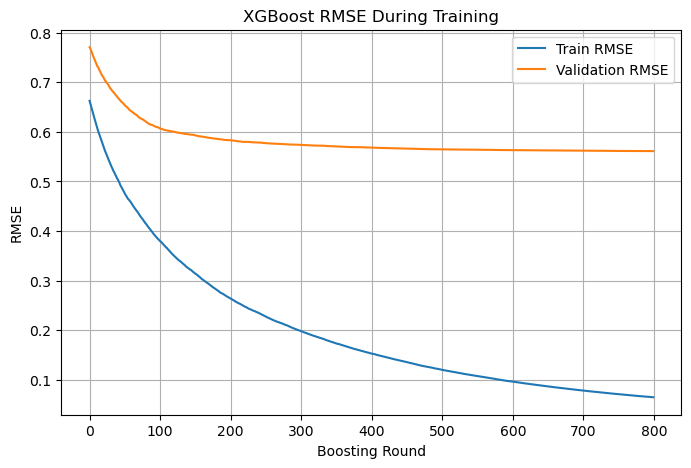

In [125]:
train_rmse = evals_result_best['train']['rmse']
val_rmse   = evals_result_best['val']['rmse']

plt.figure(figsize=(8,5))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse,   label='Validation RMSE')
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost RMSE During Training")
plt.legend()
plt.grid(True)
plt.show()

In [126]:
best_iter = bst_best.best_iteration
print("Best iteration:", best_iter)
print("Best val score:", bst_best.best_score)


Best iteration: 798
Best val score: 0.5612351585003688


In [127]:
y_val_pred_log = bst_best.predict(dval, iteration_range=(0, best_iter + 1))
y_val_true_log = y_val

In [ ]:
# Metrics
# Use Log-space metrics
mae_log  = mean_absolute_error(y_val_true_log, y_val_pred_log)
medianea_log = median_absolute_error(y_val_true_log, y_val_pred_log)
mse_log  = mean_squared_error(y_val_true_log, y_val_pred_log)
rmse_log = np.sqrt(mse_log)
r2_log   = r2_score(y_val_true_log, y_val_pred_log)
approx_mape = (np.exp(mae_log) - 1) * 100

print("---- Validation Performance (LOG Salary) ----")
print(f"MAE (log):   {mae_log:.4f}")
print(f"MedAE (log): {medianea_log:.4f}")
print(f"RMSE (log):  {rmse_log:.4f}")
print(f"R² (log):    {r2_log:.3f}")
print(f"Approx MAPE: {approx_mape:.1f}%") # Calculates approximate %error in the linera space

---- Validation Performance (LOG Salary) ----
MAE (log):   0.2036
MedAE (log): 0.1152
RMSE (log):  0.5612
R² (log):    0.477
Approx MAPE: 22.6%


#### Evaluation over all train+val

In [ ]:
# Re-run as the variables X and y must have been modified after initial definition and get error
# Keep only feature columns in X
X = df_train_val[feature_cols]
# Set as target the log avg salary
y = df_train_val["salary_avg_year_log"]

In [ ]:
# Train the model over the full labeled dataset
X_full = X.values             # df_train_val[feature_cols]
y_full_log = y.values            # df_train_val["salary_avg_year_log"]

"""print("Right after assignment:")
print(y_full_log[:10])
print(y.values[:10])"""

dtrain_full = xgb.DMatrix(X_full, label=y_full_log)

# Use best_iter + 1 trees, no early stopping (we already validated)
bst_final = xgb.train(
    params=params_best,
    dtrain=dtrain_full,
    num_boost_round=best_iter + 1,
    evals=[(dtrain_full, "train")],
    verbose_eval=50,
)

print("Final model trained with", best_iter + 1, "trees.")


Right after assignment:
[11.66006016 11.34143702 11.77529742 12.0435596  11.76026199 12.0435596
 11.66006016 11.78638944 11.28988441 11.52440927]
[11.66006016 11.34143702 11.77529742 12.0435596  11.76026199 12.0435596
 11.66006016 11.78638944 11.28988441 11.52440927]
[0]	train-rmse:0.68495
[50]	train-rmse:0.49635
[100]	train-rmse:0.39900
[150]	train-rmse:0.33156
[200]	train-rmse:0.28290
[250]	train-rmse:0.24406
[300]	train-rmse:0.21420
[350]	train-rmse:0.19017
[400]	train-rmse:0.16928
[450]	train-rmse:0.15111
[500]	train-rmse:0.13556
[550]	train-rmse:0.12213
[600]	train-rmse:0.11073
[650]	train-rmse:0.10094
[700]	train-rmse:0.09214
[750]	train-rmse:0.08437
[798]	train-rmse:0.07738
Final model trained with 799 trees.


#### Prediction

In [ ]:
# Missing:ensure which transformations were applied to X_test before predicting

In [146]:
# Build test feature matrix with the same columns
X_test = df_test[feature_cols].copy()
dtest  = xgb.DMatrix(X_test)

# Predict in log space
y_test_pred_log = bst_final.predict(dtest)

# Convert back to yearly salary
y_test_pred_year = np.exp(y_test_pred_log)

# Attach to df_test
df_test["pred_salary_avg_year_log"] = y_test_pred_log
df_test["pred_salary_avg_year"]     = y_test_pred_year

df_test[["pred_salary_avg_year"]].head()


,pred_salary_avg_year
1,77203.789062
2,55070.183594
3,60832.625000
6,60832.625000
9,95252.984375


In [ ]:
# Perform over df_test the transformations we did over df_train_val
# LEave in X only the feature columns we are interested in
categorical_cols = [
    "title",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Generate embedding column names: desc_emb_0 to desc_emb_299
embedding_cols = [f"desc_emb_{i}" for i in range(300)]

# Union of both lists
feature_cols = categorical_cols + embedding_cols

# Keep only feature columns in X
X_test = df_test[feature_cols]
# Set as target the log avg salary
y_test = df_test["salary_avg_year_log"]
# y_test = df_test["salary_avg_year"] # To try predicting the real salary instead of log

In [94]:
dtest = xgb.DMatrix(X_test)

In [95]:
y_test_pred_log = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))


In [96]:
y_test_pred_year = np.exp(y_test_pred_log)

In [98]:
y_test_pred_year[:20]

array([ 75074.51 ,  60179.84 ,  59749.28 ,  59749.28 , 101151.625,
       166183.1  , 174647.03 , 149247.83 ,  93899.53 , 172768.8  ,
       105643.28 , 155959.22 , 214936.34 , 162036.95 , 123014.26 ,
       189970.83 , 172083.42 , 144138.31 ,  57662.883, 162140.2  ],
      dtype=float32)

In [60]:
# Convert back to original salary scale (undo log)
y_val_true = np.expm1(y_val)
y_val_pred = np.expm1(y_val_pred_log)


In [61]:
mae = mean_absolute_error(y_val_true, y_val_pred)
mse = mean_squared_error(y_val_true, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_true, y_val_pred)

print(f"Validation MAE:  {mae:,.0f}")
print(f"Validation RMSE: {rmse:,.0f}")
print(f"Validation R²:   {r2:.3f}")

Validation MAE:  127,791
Validation RMSE: 3,612,063
Validation R²:   0.608


In [ ]:
# Need to run once we have to full dataset, with converted salaries and WE for the description

#### Final code parsing Linkedin json

In [ ]:
# Purpose of the notebook: parse json schema returned by the Linkedin scraper
# OBS: not finished to parse:
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
# Specific libraries
import json
from pathlib import Path
import re

# Create the mapping dictionary from text name of state to state code. OBS: not needed for now
state_map = {
    "california": "CA"
}

# Recover file name
file_solvang = "EngineerJobs_ByLocation_Solvang.json"
path = Path(file_solvang)

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)               # expects a list[dict]

# If it's a single dict, make it a list
if isinstance(data, dict):
    data = [data]

# Flatten nested fields (company.name -> company_name)
df = pd.json_normalize(data, sep=".")

# Create offer ID using the index (checked that it is unique)
df["offer_id"] = df.index

# EXTRACT CRITERIA INFORMATION INTO COLUMNS
# Explode the criteria column: extract the content of the dict in four columns
df["criteria_dict"] = df["criteria"].apply(
    lambda lst: {d["name"]: d["value"] for d in lst}
)
criteria_expanded = df["criteria_dict"].apply(pd.Series)

df = pd.concat([df, criteria_expanded], axis=1)
df = df.drop(columns=["criteria", "criteria_dict"])

# RENAME AND REORDER COLUMNS
# Rename columns to have the same naming criteria
df = df.rename(columns={
    "company.name": "company_name",
    "company.url": "company_url",
    "Seniority level": "seniority_level",
    "Employment type": "job_type",
    "Job function": "job_function",
    "Industries": "industry"
})

# Reorder the cols as we want them
"""ordered = ['offer_id', "title", "company_name", "location", "salary",
           "description", "url", 'criteria', "seniority_level",'job_type',
           'job_function','industry','searched_position', 'searched_location',
           'applications', 'company_url']
df=df[ordered]"""

# PARSE SALARY INFORMATION
# Ensure None are numpy NaN
df["salary"] = df["salary"].replace([None, "None", ""], np.nan)

# User regular expressions to extract the information we want from the current salary column
# We define first dicts that contain the unit patterns we want to detect
_unit_patterns = [
    (r"\b(per|an|a)\s+hour\b|/hour|/hr|\bhr\b|\bhour\b", "hour"),
    (r"\b(per|an|a)\s+year\b|/year|\byr\b|\byear\b|\bannum\b", "year"),
    (r"\b(per|an|a)\s+month\b|/month|\bmo\b|\bmonth\b", "month"),
    (r"\b(per|an|a)\s+week\b|/week|\bwk\b|\bweek\b", "week"),
    # Did not see for now salaries by day, otherwise, add
]
# Same for the digits
_num_pattern = re.compile(
    r"\$?\s*([0-9]{1,3}(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?)"
)

# Function to detect the unit of time the salary is given in
def _detect_unit(text_lower):
    for pattern, unit in _unit_patterns:
        if re.search(pattern, text_lower):
            return unit
    return pd.NA

# Function to parse the content of the current salary column
def parse_salary_cell(s):
    """
    Returns (min_val, max_val, unit) where min/max are floats (NaN if not found),
    and unit in {'hour','month','year','week', NA}.
    """
    if pd.isna(s):
        return np.nan, np.nan, pd.NA
    # Remove from the string whitespaces and convert to lower case
    txt = str(s).strip()
    txt_lower = txt.lower()

    # Find all numeric parts in the string
    nums = [float(n.replace(",", "")) for n in _num_pattern.findall(txt)]
    if not nums:
        return np.nan, np.nan, _detect_unit(txt_lower)

    # If we recover one number, assign to both min and max
    # If we recover two numbers, assing as corresponds to min and max
    if len(nums) >= 2:
        low, high = sorted(nums[:2])
    else:
        low = high = nums[0]

    unit = _detect_unit(txt_lower)
    return low, high, unit

# Apply to the column and create the new columns
parsed = df["salary"].apply(parse_salary_cell)
df[["salary_min", "salary_max", "salary_unit"]] = pd.DataFrame(parsed.tolist(), index=df.index)

# PARSE LOCATION INFORMATION
# Extract from location the city and the US state
# Initialize columns
df["city"] = pd.NA
df["state"] = pd.NA

# Split location first
splits = df["location"].str.split(",")

# Compute len per row
len_location = splits.str.len()
# In first Linkedin json only get location with 2 splits, but include the rest of the code in case there are entries
# with only one split as in Indeed data
# If len_location == 1
mask1 = len_location == 1
df.loc[mask1, "city"] = pd.NA
df.loc[mask1, "state"] = splits.str[-1]
# Over this recovered state name, apply the mapping to encode the state code
df["state"] = (
    df["state"]
    .str.lower()
    .replace(state_map, regex=False)
)
# If len_location > 1
mask2 = len_location > 1
df.loc[mask2, "city"] = splits.str[-2]
df.loc[mask2, "state"] = splits.str[-1]
# Need to remove the postal code
df["state_code"] = df["state"].str.split().str[0]

# CODE TO TREAT ENTRIES IN WHICH 'salary' DOES NOT CONTAIN SALARY INFORMATION
# Try to capture the entries where salary is not None or contains a $ -> these are entries where there is
# another information in salary. May be usueful.
df_no_dollar = df[
    df["salary"].apply(lambda x: isinstance(x, str)) &
    ~df["salary"].str.contains(r"\$", na=False)
].copy()

df_no_dollar = df_no_dollar[["offer_id", "salary"]].rename(
    columns={"salary": "useful_type"}
)
len_df_no_dollar = len(df_no_dollar)
print(f"Number of entries with no salary information in 'salary' column: {len_df_no_dollar}")

# If len_df_no_dollar is not 0
if len_df_no_dollar != 0:
    df = df.merge(df_no_dollar, on="offer_id", how="left")
    # Now extract information from job_type: eliminate 'Job type '
    df["job_type"] = df["job_type"].str.replace("Job type ", "", regex=False)

    # Compare job_type and useful_type (information previously extracted from 'salary'
    # when its content is not in fact a salary). Create a col to store the comparison.
    df["job_vs_useful_match"] = None

    mask = df["useful_type"].notna()
    df.loc[mask, "job_vs_useful_match"] = (
        df.loc[mask, "job_type"] == df.loc[mask, "useful_type"]
    )
    # Print the values of 'job_vs_useful_match'. If all True and the same number than
    # "Number of entries with no salary information in 'salary' column: ", the information in
    # useful_type is the same than the one contained in "job_type".
    counts = df.value_counts("job_vs_useful_match")[True]

    # Print the values of 'job_vs_useful_match'. If all True and the same number than
    # "Number of entries with no salary information in 'salary' column: ", the information in
    # useful_type is the same than the one contained in "job_type".
    counts = df.value_counts("job_vs_useful_match")[True]
    print("Number of entries with the same content in useful_type than in job_type: ", counts)
    print("If same number, columns useful_type and job_vs_useful_match can be dropped from df")

# SAVE URL to OFFER_ID AND DROP
# Before dropping 'url', store csv with offer_id, url in case it is useful in the future.
df[["offer_id", "url"]].to_csv("offer_id_url_Linkedin.csv", index=False)

# DROP, REORDER AND STORE DF into CSV
# Columns determined to be non-useful are dropped: url, company_url, pay
df.drop(columns=["url", "company_url", "state", "location"], inplace=True)

# Reorder the df into our preferred order
print("Num cols before reordering: ", len(df.columns))
ordered = ['offer_id', "title", "company_name", 'city', 'state_code','seniority_level',
           'job_type', 'job_function', 'industry',
           "description", 'salary_min', 'salary_max', 'salary_unit',"salary",
           'searched_position', 'searched_location', 'applications']
print("Num cols after reordering: ", len(ordered))

df = df[ordered]
# To save
file_name= "jobs_linkedin_solvang.csv"
df.to_csv(file_name, index=False)
print(f"Data has been saved to file: {file_name}")

Number of entries with no salary information in 'salary' column: 0
Num cols before reordering:  17
Num cols after reordering:  17
Data has been saved to file: jobs_linkedin_solvang.csv


In [ ]:
df.columns

Index(['offer_id', 'title', 'company_name', 'city', 'state_code',
       'seniority_level', 'job_type', 'job_function', 'industry',
       'description', 'salary_min', 'salary_max', 'salary_unit', 'salary',
       'searched_position', 'searched_location', 'applications'],
      dtype='object')

In [ ]:
df.drop(columns=['description']).head()

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications
0,0,Software Developer,Tecolote Research,Goleta,CA,Entry level,Full-time,Information Technology,Business Consulting and Services and Space Research and Technology,55000.0,70000.0,year,"$55,000.00/yr - $70,000.00/yr",Software Engineer,Solvang,Over 200 applicants
1,1,Software Engineer,Teledyne Technologies Incorporated,Goleta,CA,Mid-Senior level,Full-time,Engineering and Information Technology,Software Development,NaN,NaN,<NA>,NaN,Software Engineer,Solvang,Over 200 applicants
2,2,Software Engineer,Digital Prospectors,Goleta,CA,Mid-Senior level,Contract,Information Technology and Manufacturing,"Software Development, Defense and Space Manufacturing, and Manufacturing",70.0,80.0,hour,$70.00/hr - $80.00/hr,Software Engineer,Solvang,90 applicants
3,3,Java Spring Microservice,Litmus7,Goleta,CA,Mid-Senior level,Full-time,Engineering and Information Technology,IT Services and IT Consulting,NaN,NaN,<NA>,NaN,Software Engineer,Solvang,Over 200 applicants
4,4,Software Engineer,Toyon Research Corporation,Goleta,CA,Mid-Senior level,Full-time,Engineering and Information Technology,Defense and Space Manufacturing,90000.0,140000.0,year,"$90,000.00/yr - $140,000.00/yr",Software Engineer,Solvang,135 applicants


In [ ]:
# Purpose of the notebook: parse json schema returned by the indeed scraper
# OBS: not finished to parse: 'shift_schedule', 'work_setting'
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
# Specific libraries
import json
from pathlib import Path
import re

# Create the mapping dictionary from text name of state to state code
state_map = {
    "california": "CA"
}

path = Path("indeed_jobs.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)               # expects a list[dict]

# If it's a single dict, make it a list
if isinstance(data, dict):
    data = [data]

# Flatten nested fields (company.name -> company_name)
df = pd.json_normalize(data, sep=".")

# Create offer ID using the index (checked that it is unique)
df["offer_id"] = df.index
# Rename columns to have the same naming criteria
df = df.rename(columns={
    "company.name": "company_name",
    "company.url": "company_url",
    "criteria.Pay": "pay",
    "criteria.Job type": "job_type",
    "criteria.Shift and schedule": "shift_schedule",
    "criteria.Work setting": "work_setting"
})
# Reorder
cols_order=["offer_id", "title", "company_name", "location", "salary", 'pay', 'job_type', 'shift_schedule', 'work_setting', "description","url", "company_url"]
df=df[cols_order]

# Ensure core columns exist even if missing in some entries
for col in ["url", "title", "company_name", "company_url", "location", "salary", "description"]:
    if col not in df.columns:
        df[col] = pd.NA

# Ensure None are numpy NaN
df["salary"] = df["salary"].replace([None, "None", ""], np.nan)

# User regular expressions to extract the information we want from the current salary column
# We define first dicts that contain the unit patterns we want to detect
_unit_patterns = [
    (r"\b(per|an|a)\s+hour\b|/hour|/hr|\bhr\b|\bhour\b", "hour"),
    (r"\b(per|an|a)\s+year\b|/year|\byr\b|\byear\b|\bannum\b", "year"),
    (r"\b(per|an|a)\s+month\b|/month|\bmo\b|\bmonth\b", "month"),
    (r"\b(per|an|a)\s+week\b|/week|\bwk\b|\bweek\b", "week"),
    # Did not see for now salaries by day, otherwise, add
]
# Same for the digits
_num_pattern = re.compile(
    r"\$?\s*([0-9]{1,3}(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?)"
)

# Function to detect the unit of time the salary is given in
def _detect_unit(text_lower):
    for pattern, unit in _unit_patterns:
        if re.search(pattern, text_lower):
            return unit
    return pd.NA

# Function to parse the content of the current salary column
def parse_salary_cell(s):
    """
    Returns (min_val, max_val, unit) where min/max are floats (NaN if not found),
    and unit in {'hour','month','year','week', NA}.
    """
    if pd.isna(s):
        return np.nan, np.nan, pd.NA
    # Remove from the string whitespaces and convert to lower case
    txt = str(s).strip()
    txt_lower = txt.lower()

    # Find all numeric parts in the string
    nums = [float(n.replace(",", "")) for n in _num_pattern.findall(txt)]
    if not nums:
        return np.nan, np.nan, _detect_unit(txt_lower)

    # If we recover one number, assign to both min and max
    # If we recover two numbers, assing as corresponds to min and max
    if len(nums) >= 2:
        low, high = sorted(nums[:2])
    else:
        low = high = nums[0]

    unit = _detect_unit(txt_lower)
    return low, high, unit

# Apply to the column and create the new columns
parsed = df["salary"].apply(parse_salary_cell)
df[["salary_min", "salary_max", "salary_unit"]] = pd.DataFrame(parsed.tolist(), index=df.index)

# Extract from location the city and the US state
# Initialize columns
df["city"] = pd.NA
df["state"] = pd.NA

# Split location first
splits = df["location"].str.split(",")

# Compute len per row
len_location = splits.str.len()

# If len_location == 1
mask1 = len_location == 1
df.loc[mask1, "city"] = pd.NA
df.loc[mask1, "state"] = splits.str[-1]
# Over this recovered state name, apply the mapping to encode the state code
df["state"] = (
    df["state"]
    .str.lower()
    .replace(state_map, regex=False)
)

# If len_location > 1
mask2 = len_location > 1
df.loc[mask2, "city"] = splits.str[-2]
df.loc[mask2, "state"] = splits.str[-1]

# df.drop(columns=["prov"], inplace=True)
# Need to remove the postal code
df["state_code"] = df["state"].str.split().str[0]

# Columns determined to be non-useful are dropped: url, company_url, pay
# However, store csv with offer_id, url in case it is useful in the future.
df[["offer_id", "url"]].to_csv("offer_id_url.csv", index=False)

# Drop
df.drop(columns=["url", "company_url", "state"], inplace=True)

# Try to capture the entries where salary is not None or contains a $ -> these are entries where there is
# another information in salary. May be usueful.
df_no_dollar = df[
    df["salary"].apply(lambda x: isinstance(x, str)) &
    ~df["salary"].str.contains(r"\$", na=False)
].copy()

df_no_dollar = df_no_dollar[["offer_id", "salary"]].rename(
    columns={"salary": "useful_type"}
)
print(f"Number of entries with no salary information in 'salary' column: {len(df_no_dollar)}")
df = df.merge(df_no_dollar, on="offer_id", how="left")

# Now extract information from job_type: eliminate 'Job type '
df["job_type"] = df["job_type"].str.replace("Job type ", "", regex=False)

# Compare job_type and useful_type (information previously extracted from 'salary'
# when its content is not in fact a salary). Create a col to store the comparison.
df["job_vs_useful_match"] = None

mask = df["useful_type"].notna()
df.loc[mask, "job_vs_useful_match"] = (
    df.loc[mask, "job_type"] == df.loc[mask, "useful_type"]
)
# Print the values of 'job_vs_useful_match'. If all True and the same number than
# "Number of entries with no salary information in 'salary' column: ", the information in
# useful_type is the same than the one contained in "job_type".
counts = df.value_counts("job_vs_useful_match")[True]
print("Number of entries with the same content in useful_type than in job_type: ", counts)
print("If same number, columns useful_type and job_vs_useful_match can be dropped from df")
# Then, if needed, drop 'useful_type' and 'job_vs_useful_match' columns.
# ------------------------------------------------------------------------------
# MISSING CODE YET
# Parse: 'shift_schedule', 'work_setting'
# ------------------------------------------------------------------------------
# Last drop of unnecessary columns: location
df.drop(columns=["location", 'shift_schedule', 'work_setting'], inplace=True)

# Reorder the df into our preferred order
ordered = ['offer_id', "title", "company_name", 'city', 'state_code','job_type', "description", 'salary_min', 'salary_max', 'salary_unit',"salary",'useful_type', 'job_vs_useful_match']

df = df[ordered]
# To save
file_name= "jobs_indeed.csv"
df.to_csv(file_name, index=False)
print(f"Data has been saved to file: {file_name}")

Number of entries with no salary information in 'salary' column: 9
Number of entries with the same content in useful_type than in job_type:  9
If same number, columns useful_type and job_vs_useful_match can be dropped from df
Data has been saved to file: jobs_indeed.csv


In [ ]:
# # Purpose of the notebook: parse json schema returned by the indeed scraper
# OBS: not finished to parse several columns: Criteria.Pay
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
# Specific libraries
import json
from pathlib import Path
import re

# Create the mapping dictionary from text name of state to state code
state_map = {
    "california": "CA"
}

path = Path("indeed_jobs.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)               # expects a list[dict]

# If it's a single dict, make it a list
if isinstance(data, dict):
    data = [data]

# Flatten nested fields (company.name -> company_name)
df = pd.json_normalize(data, sep=".")

# Create offer ID using the index (checked that it is unique)
df["offer_id"] = df.index
# Rename columns to have the same naming criteria
df = df.rename(columns={
    "company.name": "company_name",
    "company.url": "company_url",
    "criteria.Pay": "pay",
    "criteria.Job type": "job_type",
    "criteria.Shift and schedule": "shift_schedule",
    "criteria.Work setting": "work_setting"
})
# Reorder
cols_order=["offer_id", "title", "company_name", "location", "salary", 'pay', 'job_type', 'shift_schedule', 'work_setting', "description","url", "company_url"]
df=df[cols_order]

# Ensure core columns exist even if missing in some entries
for col in ["url", "title", "company_name", "company_url", "location", "salary", "description"]:
    if col not in df.columns:
        df[col] = pd.NA

# Ensure None are numpy NaN
df["salary"] = df["salary"].replace([None, "None", ""], np.nan)

# User regular expressions to extract the information we want from the current salary column
# We define first dicts that contain the unit patterns we want to detect
_unit_patterns = [
    (r"\b(per|an|a)\s+hour\b|/hour|/hr|\bhr\b|\bhour\b", "hour"),
    (r"\b(per|an|a)\s+year\b|/year|\byr\b|\byear\b|\bannum\b", "year"),
    (r"\b(per|an|a)\s+month\b|/month|\bmo\b|\bmonth\b", "month"),
    (r"\b(per|an|a)\s+week\b|/week|\bwk\b|\bweek\b", "week"),
    # Did not see for now salaries by day, otherwise, add
]
# Same for the digits
_num_pattern = re.compile(
    r"\$?\s*([0-9]{1,3}(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?)"
)

# Function to detect the unit of time the salary is given in
def _detect_unit(text_lower):
    for pattern, unit in _unit_patterns:
        if re.search(pattern, text_lower):
            return unit
    return pd.NA

# Function to parse the content of the current salary column
def parse_salary_cell(s):
    """
    Returns (min_val, max_val, unit) where min/max are floats (NaN if not found),
    and unit in {'hour','month','year','week', NA}.
    """
    if pd.isna(s):
        return np.nan, np.nan, pd.NA
    # Remove from the string whitespaces and convert to lower case
    txt = str(s).strip()
    txt_lower = txt.lower()

    # Find all numeric parts in the string
    nums = [float(n.replace(",", "")) for n in _num_pattern.findall(txt)]
    if not nums:
        return np.nan, np.nan, _detect_unit(txt_lower)

    # If we recover one number, assign to both min and max
    # If we recover two numbers, assing as corresponds to min and max
    if len(nums) >= 2:
        low, high = sorted(nums[:2])
    else:
        low = high = nums[0]

    unit = _detect_unit(txt_lower)
    return low, high, unit

# Apply to the column and create the new columns
parsed = df["salary"].apply(parse_salary_cell)
df[["salary_min", "salary_max", "salary_unit"]] = pd.DataFrame(parsed.tolist(), index=df.index)

# Extract from location the city and the US state
# Initialize columns
df["city"] = pd.NA
df["state"] = pd.NA

# Split location first
splits = df["location"].str.split(",")

# Compute len per row
len_location = splits.str.len()

# If len_location == 1
mask1 = len_location == 1
df.loc[mask1, "city"] = pd.NA
df.loc[mask1, "state"] = splits.str[-1]
# Over this recovered state name, apply the mapping to encode the state code
df["state"] = (
    df["state"]
    .str.lower()
    .replace(state_map, regex=False)
)

# If len_location > 1
mask2 = len_location > 1
df.loc[mask2, "city"] = splits.str[-2]
df.loc[mask2, "state"] = splits.str[-1]

# df.drop(columns=["prov"], inplace=True)
# Need to remove the postal code
df["state_code"] = df["state"].str.split().str[0]

# Columns determined to be non-useful are dropped: url, company_url, pay
# However, store csv with offer_id, url in case it is useful in the future.
df[["offer_id", "url"]].to_csv("offer_id_url.csv", index=False)

# Drop
df.drop(columns=["url", "company_url", "state"], inplace=True)

# Try to capture the entries where salary is not None or contains a $ -> these are entries where there is
# another information in salary. May be usueful.
df_no_dollar = df[
    df["salary"].apply(lambda x: isinstance(x, str)) &
    ~df["salary"].str.contains(r"\$", na=False)
].copy()

df_no_dollar = df_no_dollar[["offer_id", "salary"]].rename(
    columns={"salary": "useful_type"}
)
print(len(df_no_dollar))
df = df.merge(df_no_dollar, on="offer_id", how="left")

# Now extract information from job_type: eliminate 'Job type '
df["job_type"] = df["job_type"].str.replace("Job type ", "", regex=False)

# Compare job_type and useful_type (information previously extracted from 'salary'
# when its content is not in fact a salary). Create a col to store the comparison.
df["job_vs_useful_match"] = None

mask = df["useful_type"].notna()
# print("Number of entries that have a useful_type not NA: ", len(mask))
df.loc[mask, "job_vs_useful_match"] = (
    df.loc[mask, "job_type"] == df.loc[mask, "useful_type"]
)
# Print the values of 'job_vs_useful_match'. If all True and the same number than
# "Number of entries that have a useful_type not NA: ", the information in
# useful_type is the same than the one contained in "job_type".
df.value_counts("job_vs_useful_match")

# Then, if needed, drop 'useful_type' and 'job_vs_useful_match' columns.
# ------------------------------------------------------------------------------
# MISSING CODE YET
# Parse: 'shift_schedule', 'work_setting'
# ------------------------------------------------------------------------------
# Last drop of unnecessary columns: location
df.drop(columns=["location", 'shift_schedule', 'work_setting'], inplace=True)

# Reorder the df into our preferred order
ordered = ['offer_id', "title", "company_name", 'city', 'state_code','job_type', "description",
           'salary_min', 'salary_max', 'salary_unit',"salary",'useful_type', 'job_vs_useful_match']
df = df[ordered]
# To save
file_name= "jobs_indeed.csv"
df.to_csv(file_name, index=False)
print(f"Data has been saved to file: {file_name}")

9
Number of entries that have a useful_type not NA:  75
Data has been saved to file: jobs_indeed.csv
